# CFPB Credit Card Complaints — Exploratory Data Analysis

## Goal
Analyse consumer credit card complaints from the CFPB dataset to identify
patterns that predict whether a dispute is resolved in favour of the consumer or not.

## Key Questions
1. How imbalanced is the dispute outcome label? — defines training strategy and threshold calibration
2. Which complaint types and sub-products carry the most predictive signal for dispute outcome?
3. Are there temporal patterns in complaint volume or resolution rates worth engineering as features?
4. What is the missing data profile across key columns? — informs preprocessing pipeline design
5. What is the cardinality of categorical features (company, product, issue)? — affects encoding strategy and memory footprint
6. How does response time (date received → date sent) correlate with dispute outcome? — latency as a domain feature
7. What are the memory and I/O characteristics of loading and processing this dataset? — benchmark DataFrame size, dtypes footprint, and read time as a baseline for pipeline design

## Dataset
Source: US Consumer Finance Complaints — CFPB via Kaggle
Download: https://www.kaggle.com/datasets/kaggle/us-consumer-finance-complaints

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [98]:
file_name= "../data/consumer_complaints.csv"
df = pd.read_csv(file_name, low_memory=False)

### Initial inspection
Let's inspect the shape to see how many columns and rows we have and the columns details

In [99]:
df.shape
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 555957 entries, 0 to 555956
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   date_received                 555957 non-null  str  
 1   product                       555957 non-null  str  
 2   sub_product                   397635 non-null  str  
 3   issue                         555957 non-null  str  
 4   sub_issue                     212622 non-null  str  
 5   consumer_complaint_narrative  66806 non-null   str  
 6   company_public_response       85124 non-null   str  
 7   company                       555957 non-null  str  
 8   state                         551070 non-null  str  
 9   zipcode                       551452 non-null  str  
 10  tags                          77959 non-null   str  
 11  consumer_consent_provided     123458 non-null  str  
 12  submitted_via                 555957 non-null  str  
 13  date_sent_to_company     

> **Data structure Note:** Analyse the type of products to filter by Credit cards

In [100]:
df['product'].value_counts()

product
Mortgage                   186475
Debt collection            101052
Credit reporting            91854
Credit card                 66468
Bank account or service     62563
Consumer Loan               20990
Student loan                15839
Payday loan                  3877
Money transfers              3812
Prepaid card                 2470
Other financial service       557
Name: count, dtype: int64

### Filter: Credit Card complaints only

> **Infrastructure Note:** filtering in-place (`df = df[...]`) rather than using `.copy()` drops the reference to the full 555k-row DataFrame, allowing the garbage collector to reclaim ~560 MB. At this scale the difference is minor, but on GB-sized datasets avoiding unnecessary copies is a first-class concern — peak memory during a copy can be 2x the DataFrame size.

In [101]:
df = df[df['product'] == 'Credit card']


In [102]:
df.drop(columns=['product'], inplace=True)
print(df.shape)

(66468, 17)


In [103]:
df['consumer_disputed?'].value_counts(normalize=True)

consumer_disputed?
No     0.792171
Yes    0.207829
Name: proportion, dtype: float64

### Target Variable Analysis — `consumer_disputed?`

> **Problem type:** Binary classification — `consumer_disputed?` is either `"Yes"` (consumer opened a dispute) or `"No"` (didn't dispute).

> **Class imbalance:** 79.2% No / 20.8% Yes (~4:1 ratio). The dataset is imbalanced but not extreme.

> **Accuracy trap:** A model that always predicts "No" achieves 79% accuracy without learning anything — it has 0% recall on the minority class and never catches a real dispute. Accuracy is a misleading metric here.

In [104]:
df.isnull().sum().sort_values()

date_received                       0
timely_response                     0
company_response_to_consumer        0
date_sent_to_company                0
submitted_via                       0
consumer_disputed?                  0
complaint_id                        0
issue                               0
company                             0
zipcode                           585
state                             593
consumer_consent_provided       53030
tags                            56556
company_public_response         58137
consumer_complaint_narrative    58539
sub_issue                       66468
sub_product                     66468
dtype: int64

### Missing Data Analysis

> **Dropped columns (>80% null):** `sub_issue`, `sub_product`, `consumer_complaint_narrative`, `company_public_response`, `tags`, `consumer_consent_provided` — these fields were not captured for credit card complaints and carry no signal.

> **Remaining nulls:** `state` (593) and `zipcode` (585) — ~0.9% of rows. Geographic data is missing for a small fraction of complaints.

> **Imputation decision:** Mean imputation is not applicable to categorical/geographic columns. Options are: most-frequent value (introduces false signal), row removal (loses valid complaint data), or placeholder `"Unknown"` (honest — treats missing geography as its own category). Decision is to use "Unknown"

### Other unuseful columns
> **complaint_id** is just an identifier, no predictive signal

> **Data leakage:** `company_response_to_consumer` and `timely_response` are both generated *after* the company has processed the complaint — they would not be available at the moment a new complaint arrives and a prediction is needed. Using them as features would mean training the model with information from the future relative to prediction time. Both are dropped.

In [105]:
df['state'] = df['state'].fillna('Unknown')
df['zipcode'] = df['zipcode'].fillna('Unknown')
print(df.isnull().sum())

date_received                       0
sub_product                     66468
issue                               0
sub_issue                       66468
consumer_complaint_narrative    58539
company_public_response         58137
company                             0
state                               0
zipcode                             0
tags                            56556
consumer_consent_provided       53030
submitted_via                       0
date_sent_to_company                0
company_response_to_consumer        0
timely_response                     0
consumer_disputed?                  0
complaint_id                        0
dtype: int64


In [106]:
df.drop(columns=['consumer_consent_provided', 'tags', 'company_public_response', 'consumer_complaint_narrative', 'sub_issue', 'sub_product', 'complaint_id', 'company_response_to_consumer', 'timely_response'], inplace=True, errors='ignore')
print(df.shape)

(66468, 8)


In [107]:
df.nunique()

date_received            1605
issue                      33
company                   359
state                      63
zipcode                 14669
submitted_via               6
date_sent_to_company     1517
consumer_disputed?          2
dtype: int64

### Cardinality Analysis

> **Too high to encode directly:**
> - `zipcode` (14,669 unique values) — one-hot encoding would create 14,669 columns, exploding memory with no real signal
> - `company` (359) — high cardinality, needs a grouping or frequency-based strategy before encoding

> **Date columns — need feature engineering, not encoding:**
> - `date_received` (1,605) and `date_sent_to_company` (1,517) are not categorical — features like year, month, and day of week should be extracted instead

> **Manageable cardinality — safe to encode:**
> - `issue` (33), `state` (63), `submitted_via` (6)

In [108]:
df.groupby('issue')['consumer_disputed?'].value_counts(normalize=True)
pd.crosstab(df['issue'], df['consumer_disputed?'], normalize='index').sort_values(by='Yes')


consumer_disputed?,No,Yes
issue,,
Late fee,0.862191,0.137809
Other fee,0.858513,0.141487
Unsolicited issuance of credit card,0.835498,0.164502
Billing statement,0.823413,0.176587
Payoff process,0.822899,0.177101
Cash advance fee,0.817610,0.182390
Application processing delay,0.813299,0.186701
Identity theft / Fraud / Embezzlement,0.813189,0.186811
Sale of account,0.812000,0.188000


### Predictive Signal — `issue` vs dispute outcome

> **Finding:** Dispute rates across all issue types range from 13.8% (`Late fee`) to 29.5% (`Cash advance`) — a spread of only ~16 percentage points around the overall baseline of 20.8%.

> **Interpretation:** Fee-related issues (`Late fee`, `Other fee`, `Cash advance fee`) have the lowest dispute rates — consumers accept the charge even if unhappy. Issues involving account changes or unexpected transactions (`Cash advance`, `Convenience checks`, `Arbitration`) have the highest dispute rates — consumers feel something was done without their consent.

> **Conclusion:** `issue` has weak predictive signal. No single issue type dramatically breaks away from the baseline, meaning this feature alone would not give a model much to work with.

In [109]:
df.groupby('company')['consumer_disputed?'].value_counts(normalize=True)
pd.crosstab(df['company'], df['consumer_disputed?'], normalize='index').sort_values(by='Yes')


consumer_disputed?,No,Yes
company,,
ACE Cash Express Inc.,1.0,0.0
"National Check Bureau, Inc.",1.0,0.0
"NCC Business Services, Inc.",1.0,0.0
"NCB Management Services, Inc.",1.0,0.0
MoneyGram,1.0,0.0
...,...,...
Astoria Bank,0.0,1.0
"Asta Funding, Inc",0.0,1.0
"Asset Management Professionals, LLC",0.0,1.0


In [110]:
# Step 1 — get companies with more than 100 complaints
company_counts = df['company'].value_counts()
valid_companies = company_counts[company_counts > 100].index

# Step 2 — filter df to only those companies, then crosstab
df_top = df[df['company'].isin(valid_companies)]
pd.crosstab(df_top['company'], df_top['consumer_disputed?'], normalize='index').sort_values(by='Yes', ascending=False)



consumer_disputed?,No,Yes
company,,
Amex,0.717727,0.282273
TD Bank US Holding Company,0.748884,0.251116
First National Bank of Omaha,0.756044,0.243956
JPMorgan Chase & Co.,0.758811,0.241189
Bank of America,0.769657,0.230343
Pentagon FCU,0.771186,0.228814
Wells Fargo & Company,0.780186,0.219814
U.S. Bancorp,0.781596,0.218404
"Citizens Financial Group, Inc.",0.787234,0.212766


### Predictive Signal — `company` vs dispute outcome

> **Methodology:** Companies with fewer than 100 complaints were excluded to avoid noise from small sample sizes (a single complaint going one way would skew to 0% or 100%).

> **Finding:** Dispute rates across companies with sufficient volume range from 13.9% (`SunTrust`) to 28.2% (`Amex`) — a spread of ~14 percentage points around the 20.8% baseline. Same pattern as `issue`.

> **Conclusion:** `company` also has weak predictive signal. Neither complaint type nor company identity is a strong driver of dispute outcome in this dataset.

> **Overall Q2 finding:** This dataset has limited predictive features for dispute outcome. Both `issue` and `company` show weak signal. A production model would need enrichment with additional data — transaction history, customer tenure, previous dispute behaviour, or response time deltas — to achieve meaningful predictive power.

In [111]:
df['date_received'] = pd.to_datetime(df['date_received'])
df['date_sent_to_company'] = pd.to_datetime(df['date_sent_to_company'])

<Axes: xlabel='date_received'>

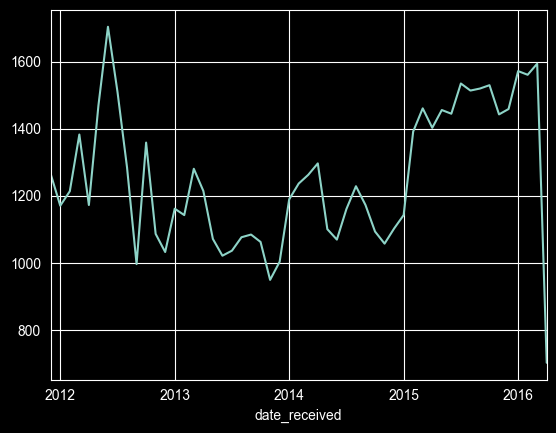

In [112]:

date_series = df['date_received'].dt.to_period('M').value_counts().sort_index()
date_series.plot()

<Axes: xlabel='date_received'>

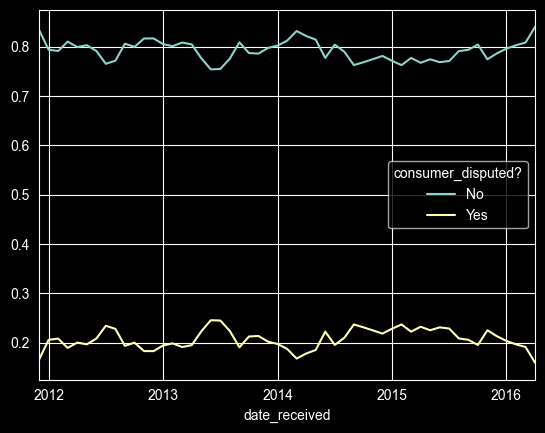

In [113]:
date_series = pd.crosstab(df['date_received'].dt.to_period('M'), df['consumer_disputed?'], normalize='index').sort_index()
date_series.plot()

### Temporal Analysis — Complaint Volume and Dispute Rates

> **Complaint volume:** Three phases visible — high volume in late 2011/early 2012, relative stability with minor variation through 2013–2014, then a recovery and increase from 2015 onward. The sharp drop in April 2016 is not a real trend — the dataset is truncated mid-month.

> **Dispute rates over time:** Stable throughout the entire period, consistently hovering around the 20.8% baseline with no seasonal pattern or trend.

> **Conclusion:** Temporal features derived from `date_received` (year, month) are unlikely to add predictive signal for dispute outcome. The date alone does not move the dispute rate.

In [114]:
df['response_days'] = (df['date_sent_to_company'] - df['date_received']).dt.days
df['response_days'].describe()

count    66468.000000
mean         3.082732
std         12.601596
min         -1.000000
25%          0.000000
50%          1.000000
75%          3.000000
max        993.000000
Name: response_days, dtype: float64

In [115]:
df = df[(df['response_days'] >= 0) & (df['response_days'] <= 27)]
df.shape



(64388, 9)

In [116]:
df.groupby('consumer_disputed?')['response_days'].mean()

consumer_disputed?
No     2.174664
Yes    2.054642
Name: response_days, dtype: float64

### Response Time Analysis — Q6


> Firstly, calculate the response time as the time between the **'date_received'** and the **'date_sent_to_company'**

> **Data cleaning:** Removed 2,080 rows (3.1%) — 1,162 with negative response days (corrupt data) and ~918 outliers above 27 days (mean + 2×std threshold).

> **Finding:** Mean response time for disputed complaints (2.05 days) vs non-disputed (2.17 days) — a difference of less than 0.2 days.

> **Conclusion:** Response time has no meaningful correlation with dispute outcome. How quickly the complaint was forwarded to the company does not predict whether the consumer will dispute the resolution.

In [117]:
df.memory_usage(deep=True).sum() / 1024**2


np.float64(22.938875198364258)

### Infrastructure Notes— Q7

> **Original Dataset size:** 560,8MB
>
> **Final Dataset size:** 22,9MB . 555,957 rows × 18 columns → 64,388 rows × 9 columns. Row reduction due to firstly "credit card" complaints filtering in the product and secondly due to data cleaning (nulls values, corrupt data, outliers). Column reduction after identifying columns not captured for credit card complaints (>80% null), an identifier with no signal (`complaint_id`), and two columns with data leakage (`company_response_to_consumer`, `timely_response`).
>
> **CSV read time:** 1,5s (Acceptable)
>
> **Dataset types:** All object dtype strings in pandas are stored as Python objects (expensive). Converting to pd.Categorical dtype stores values as integer codes internally, reducing memory footprint. One-hot encoding is a separate step for model input, not a storage optimization. This is a potential optimization not done in this module
>